<a href="https://colab.research.google.com/github/Venumadhav-18/Power-Plant-Energy-Prediction/blob/main/Power_Plant_Project(_Regression_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.**  feature scaling cheyali , to reduce all the value to same length
**2.**   then train and test the data
**3.** now implement the models of regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset=pd.read_csv("Model_Selection_Project.csv")

In [4]:
dataset=dataset.dropna(how='all')
dataset=dataset.dropna(axis=1,how='all')

In [5]:
x=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [8]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [9]:
from sklearn.tree import DecisionTreeRegressor
model1=DecisionTreeRegressor(random_state=0)
model1.fit(x_train,y_train)

DecisionTreeRegressor(random_state=0)

In [10]:
from sklearn.ensemble import RandomForestRegressor
model2=RandomForestRegressor(n_estimators=100,random_state=0)
model2.fit(x_train,y_train)

RandomForestRegressor(random_state=0)

In [11]:
print(model.predict(sc.transform([[5.5,39.5,1012.52,92.5]])))
# linear regression

[482.70424898]


In [12]:
print(model1.predict(sc.transform([[5.5,39.5,1012.52,92.5]])))
# decision treee

[488.63]


In [13]:
print(model2.predict(sc.transform([[5.5,39.5,1012.52,92.5]])))
# random forest regressor

[483.999]


In [14]:
pred_y=model.predict(x_test)
# linear regression

In [15]:
pred_y1=model1.predict(x_test)
# decision tree

In [16]:
pred_y2=model2.predict(x_test)
# random forest

In [17]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,pred_y)
print(r2)
# linear regression

0.9325315554761302


In [18]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,pred_y1)
print(r2)
# decision tree

0.9231106384743017


In [19]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,pred_y2)
print(r2)
# random forest

0.9650994584080381


In [29]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "Train R2": [
        model.score(x_train, y_train),
        model1.score(x_train, y_train),
        model2.score(x_train, y_train)
    ],
    "Test R2": [
        model.score(x_test, y_test),
        model1.score(x_test, y_test),
        model2.score(x_test, y_test)
    ]
})

results

,Model,Train R2,Test R2
0,Linear Regression,0.927725,0.932532
1,Decision Tree,1.000000,0.923111
2,Random Forest,0.994550,0.965099


**Apply Decision and Random Forest**

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, pred_y))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_y)))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, pred_y2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_y2)))

Linear Regression:
MAE: 3.566564655203821
RMSE: 4.442262858442491

Random Forest:
MAE: 2.3461000522466025
RMSE: 3.19499356307536


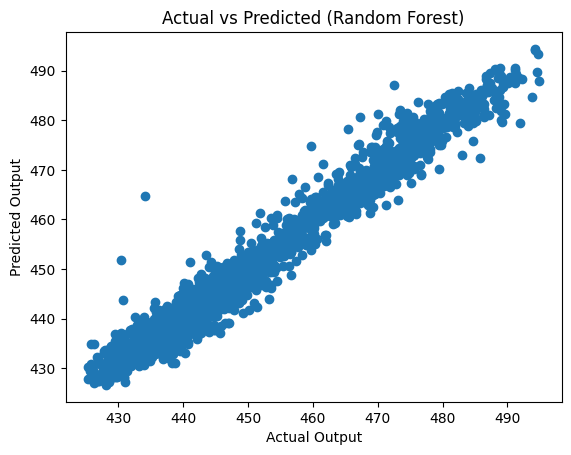

In [24]:
plt.scatter(y_test, pred_y2)
plt.xlabel("Actual Output")
plt.ylabel("Predicted Output")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

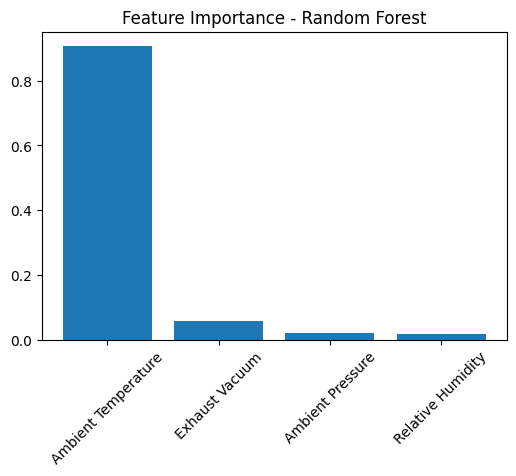

In [25]:
importance = model2.feature_importances_
features = dataset.columns[:-1]

plt.figure(figsize=(6,4))
plt.bar(features, importance)
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=45)
plt.show()

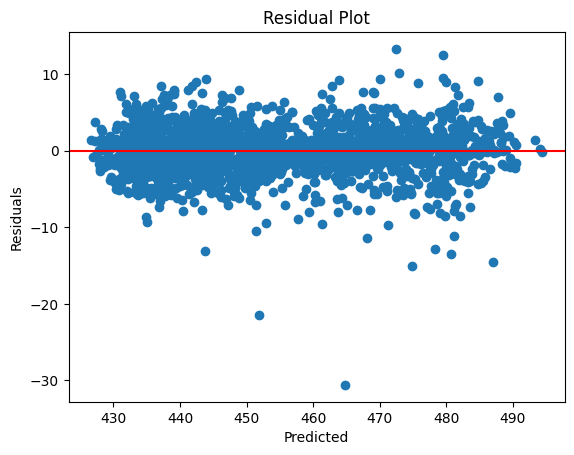

In [26]:
residuals = y_test - pred_y2

plt.scatter(pred_y2, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [30]:
import joblib

joblib.dump(model2, "power_plant_model.pkl")
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']

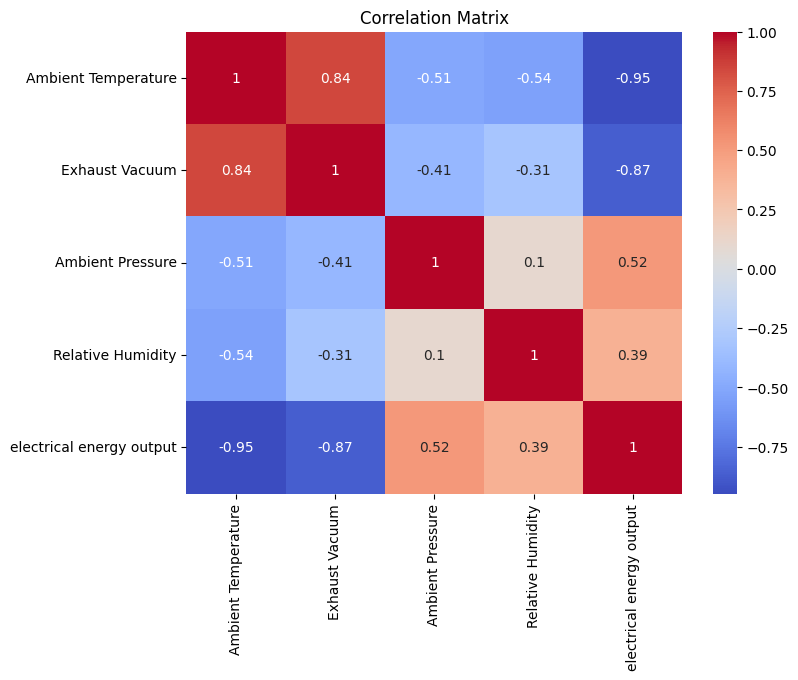

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [31]:
from google.colab import files

files.download("power_plant_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>